### Traveltime Grids 3D

This script computes 3D travel-time grids for a set of receivers in a heterogeneous velocity model.


In [1]:
using SeisTimes
using GLMakie
Makie.inline!(true);

Shape Model: (101, 101, 101)
Receivers: [(450, 245, 0), (450, 245, 20)] ... (450, 245, 500)
N-Receiver: 26


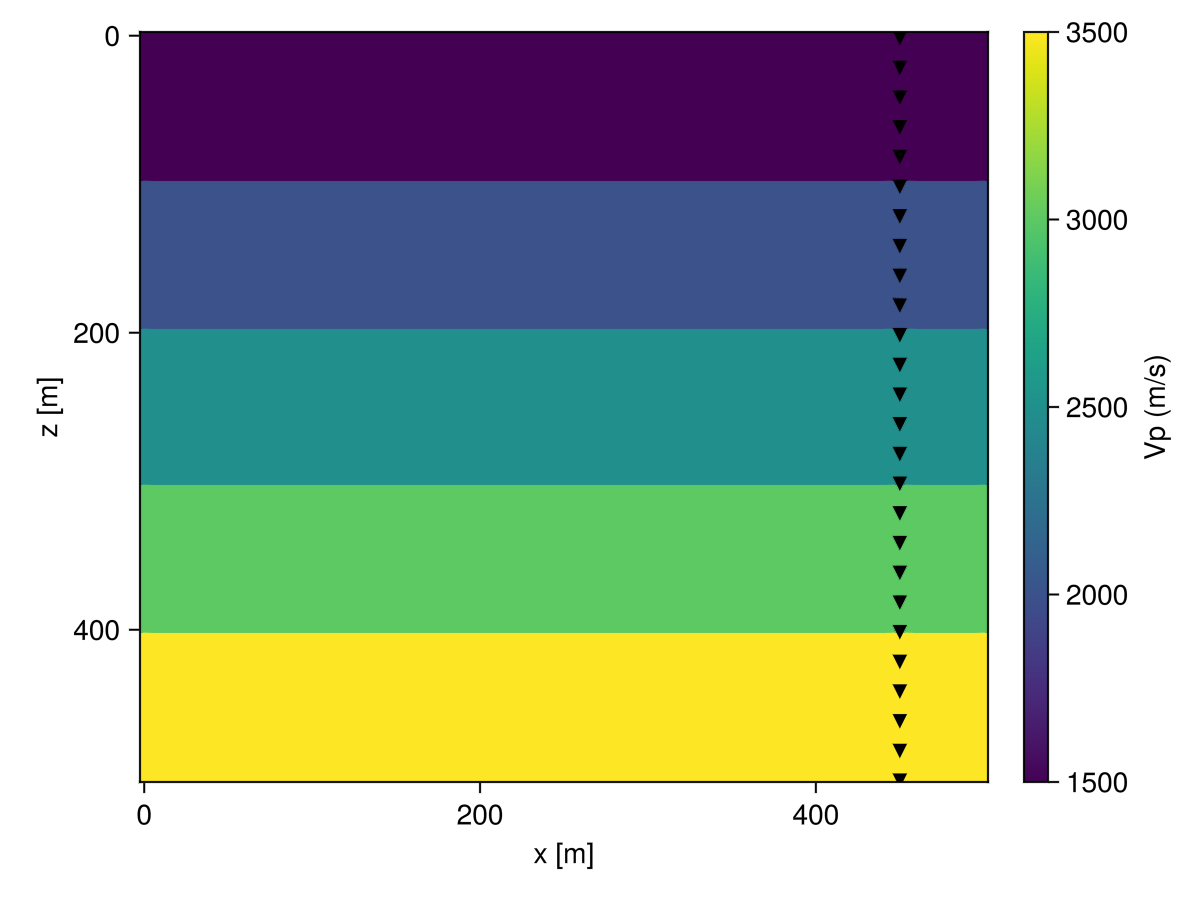

In [ ]:
# create a layered velocity model
function make_3d_layered_model(x_coords, y_coords, z_coords, v_layers)

    nx, ny, nz = length(x_coords), length(y_coords), length(z_coords)
    velocity = zeros(nx, ny, nz)
    n_layers = length(v_layers)
    layer_bounds = round.(Int, LinRange(1, nz+1, n_layers+1))

    for l in 1:n_layers
        z_start = layer_bounds[l]
        z_end = layer_bounds[l+1] - 1  
        velocity[:, :, z_start:z_end] .= v_layers[l]
    end

    return velocity
end

h = 5
x_coords = 0:h:500
y_coords = 0:h:500
z_coords = 0:h:500
nx, ny, nz = length(x_coords), length(y_coords), length(z_coords)

vp_layers = [1500, 2000, 2500, 3000, 3500]
vp = make_3d_layered_model(x_coords, y_coords, z_coords, vp_layers);

vs_layers = [1000, 1500, 1800, 2000, 2300]
vs = make_3d_layered_model(x_coords, y_coords, z_coords, vs_layers)

rho_layers = [2000, 2200, 2400, 2600, 2800]
rho = make_3d_layered_model(x_coords, y_coords, z_coords, rho_layers)

println("Shape Model: ", size(vp))

# velocity model array 
veldim = (13, nx, ny, nz)
velmod = zeros(veldim);

# meshgrid coordinates
X = getindex.(Iterators.product(x_coords, y_coords, z_coords), 1)
Y = getindex.(Iterators.product(x_coords, y_coords, z_coords), 2)
Z = getindex.(Iterators.product(x_coords, y_coords, z_coords), 3)

# fill 
velmod[1,:,:,:] .= X
velmod[2,:,:,:] .= Y
velmod[3,:,:,:] .= Z
velmod[4,:,:,:] .= vp
velmod[5,:,:,:] .= vs
velmod[6,:,:,:] .= rho 

# define receivers 
xrec = Int(floor(length(x_coords)/1.1))
yrec = Int(floor(length(y_coords)/2))

receivers = [(x_coords[xrec], y_coords[yrec], z) for z in z_coords[1:4:end]]
println("Receivers: ", receivers[1:2], " ... ", receivers[end])
println("N-Receiver: ", size(receivers,1))

# visualize
fig = Figure() 
ax = Axis(fig[1,1], xlabel="x [m]", ylabel="z [m]", yreversed=true)
img = vp[:,1,:] # x-z slice
heatmap!(ax, x_coords, z_coords, img)
Colorbar(fig[1,2], limits=(minimum(img), maximum(img)), label="Vp (m/s)")
rx = [r[1] for r in receivers]
rz = [r[3] for r in receivers]
scatter!(ax, rx, rz, color=:black, marker=:dtriangle, markersize=10)
fig


---

### Compute travel times

Instead of computing traveltimes from each possible source location seperatly, 
one can exploit the symmetry of the two-way traveltime by reversing the problem
and treat receivers as pseudo-sources.


**fast_sweep** will automatically compute travel time grids for each source in parallel using multi-threading.<br>
User need to make sure that multiple threads are available for julia on their system (https://docs.julialang.org/en/v1/manual/multi-threading/).<br>
vscode user may need to set number of threads manually in settings (see https://discourse.julialang.org/t/how-to-set-number-of-threads-for-vs-code/47434/9).

In [ ]:
#=
Jupyter notebooks are unable to properly print fast_sweep progress bar for multiple sources, so we set it here to false. 
Set to true for more detailed output in the REPL or terminal.
=#
verbose = false
fs_result = fast_sweep(velmod, receivers, :P, :LxFS5; verbose=verbose); # (this takes a while for 26x101x101x101. [9min on M2 Pro]) 

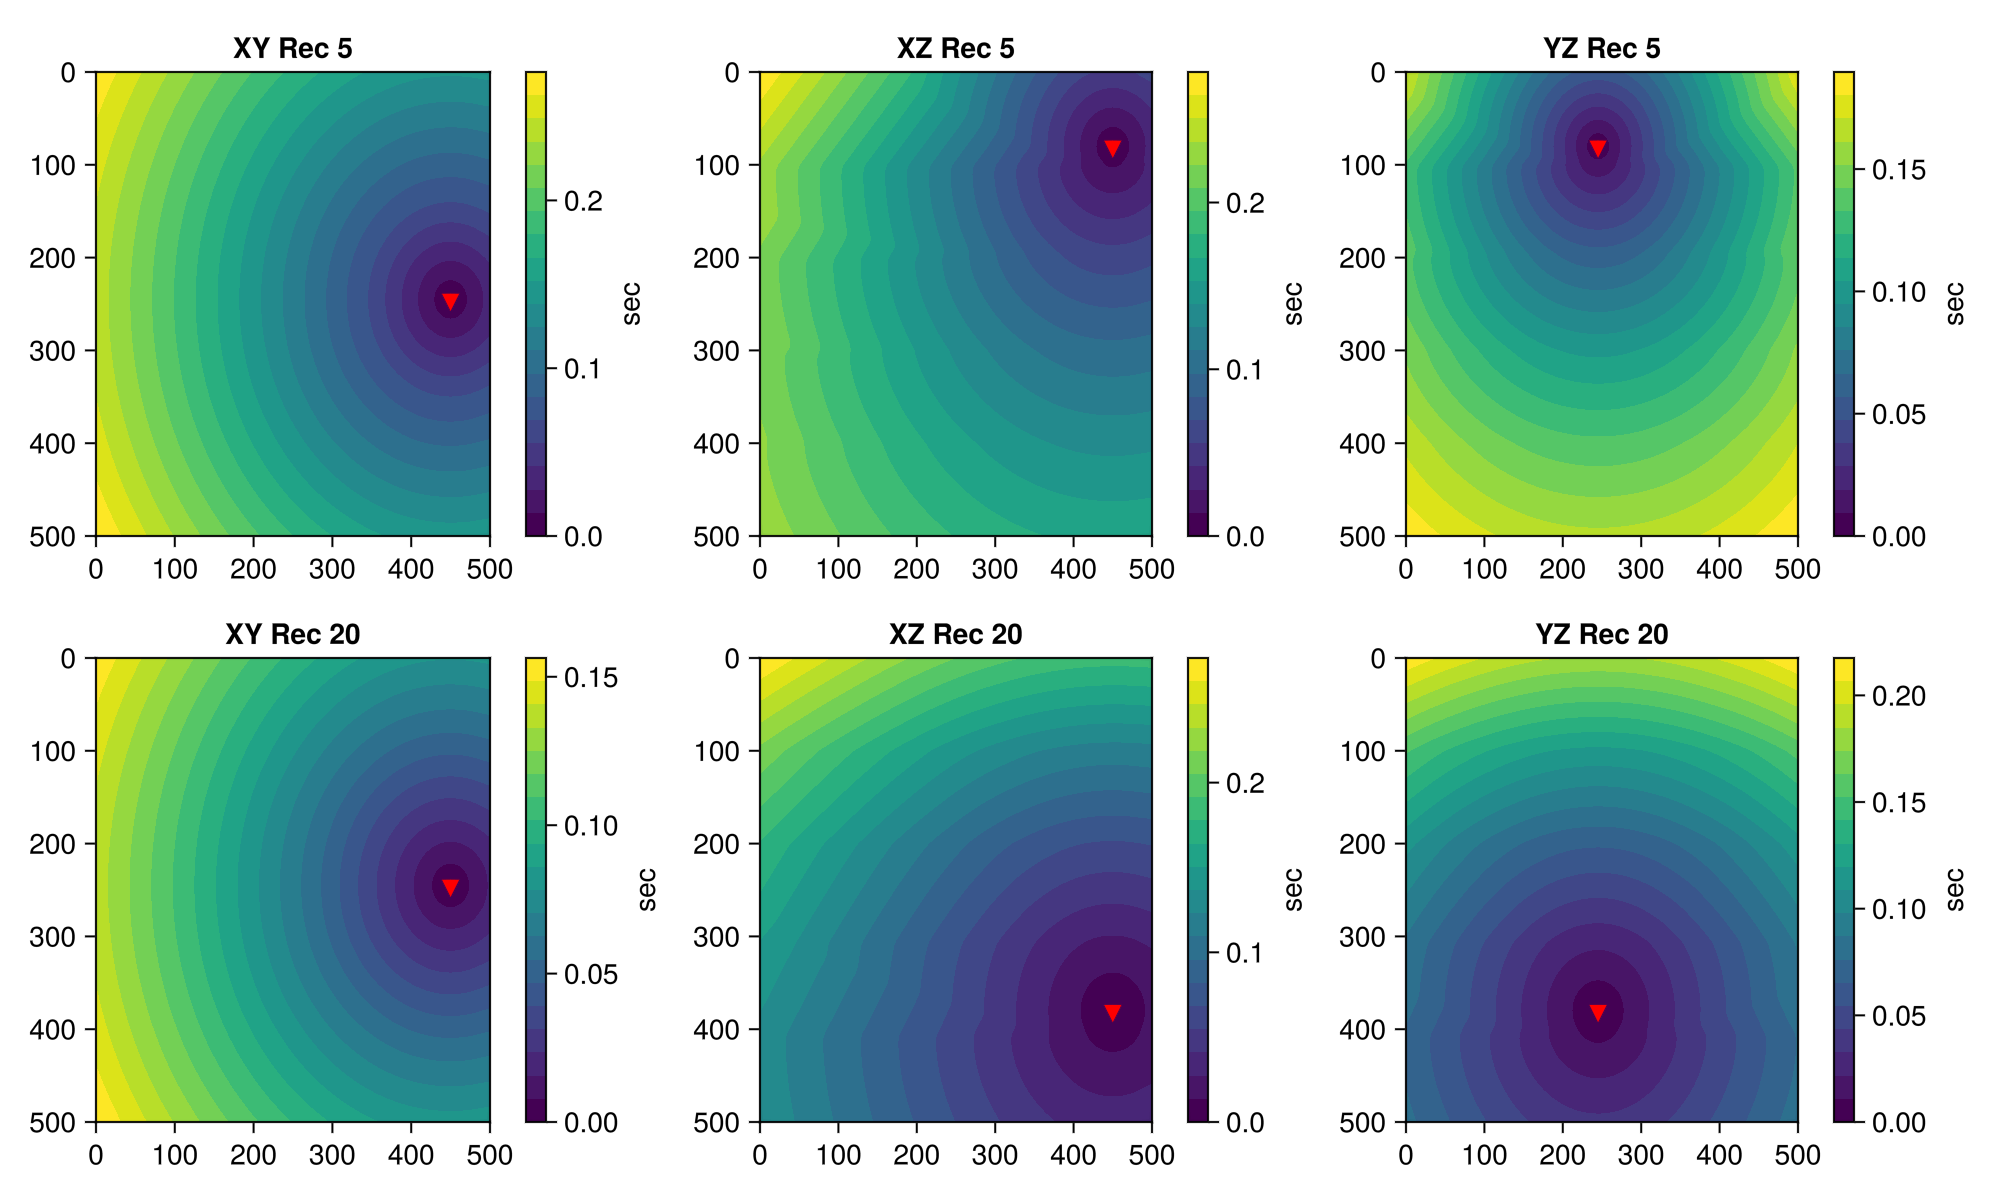

GLMakie.Screen(...)

In [12]:
# Visualize 2 receivers 

receiver_indices = (5, 20)

fig = Figure(size=(1000,600)) 

# extract slices at receiver positions
zrec1 = argmin(abs.(z_coords .- receivers[receiver_indices[1]][3]))
zrec2 = argmin(abs.(z_coords .- receivers[receiver_indices[2]][3]))
xy = [fs_result[receiver_indices[1]].traveltimes[:,:,zrec1], fs_result[receiver_indices[2]].traveltimes[:,:,zrec2]]
xz = [fs_result[receiver_indices[1]].traveltimes[:,yrec,:], fs_result[receiver_indices[2]].traveltimes[:,yrec,:]]
yz = [fs_result[receiver_indices[1]].traveltimes[xrec,:,:], fs_result[receiver_indices[2]].traveltimes[xrec,:,:]]

titles = ["Rec $(receiver_indices[1])", "Rec $(receiver_indices[2])"]
cmap = :viridis
for i in 1:2
    rx, ry, rz = receivers[receiver_indices[i]]

    # XY
    ax_xy = Axis(fig[i,1], title="XY "*titles[i], yreversed=true)
    hm_xy = contourf!(ax_xy, x_coords, y_coords, xy[i], colormap=cmap, levels=20)
    Colorbar(fig[i,2], hm_xy, width=10, label="sec")
    scatter!(ax_xy, [rx], [ry], color=:red, marker=:dtriangle, markersize=12)

    # XZ
    ax_xz = Axis(fig[i,3], title="XZ "*titles[i], yreversed=true)
    hm_xz = contourf!(ax_xz, x_coords, z_coords, xz[i], colormap=cmap, levels=20)
    Colorbar(fig[i,4], hm_xz, width=10, label="sec")
    scatter!(ax_xz, [rx], [rz], color=:red, marker=:dtriangle, markersize=12)

    # YZ
    ax_yz = Axis(fig[i,5], title="YZ "*titles[i], yreversed=true)
    hm_yz = contourf!(ax_yz, y_coords, z_coords, yz[i], colormap=cmap, levels=20)
    Colorbar(fig[i,6], hm_yz, width=10, label="sec")
    scatter!(ax_yz, [ry], [rz], color=:red, marker=:dtriangle, markersize=12)
end

display(fig)

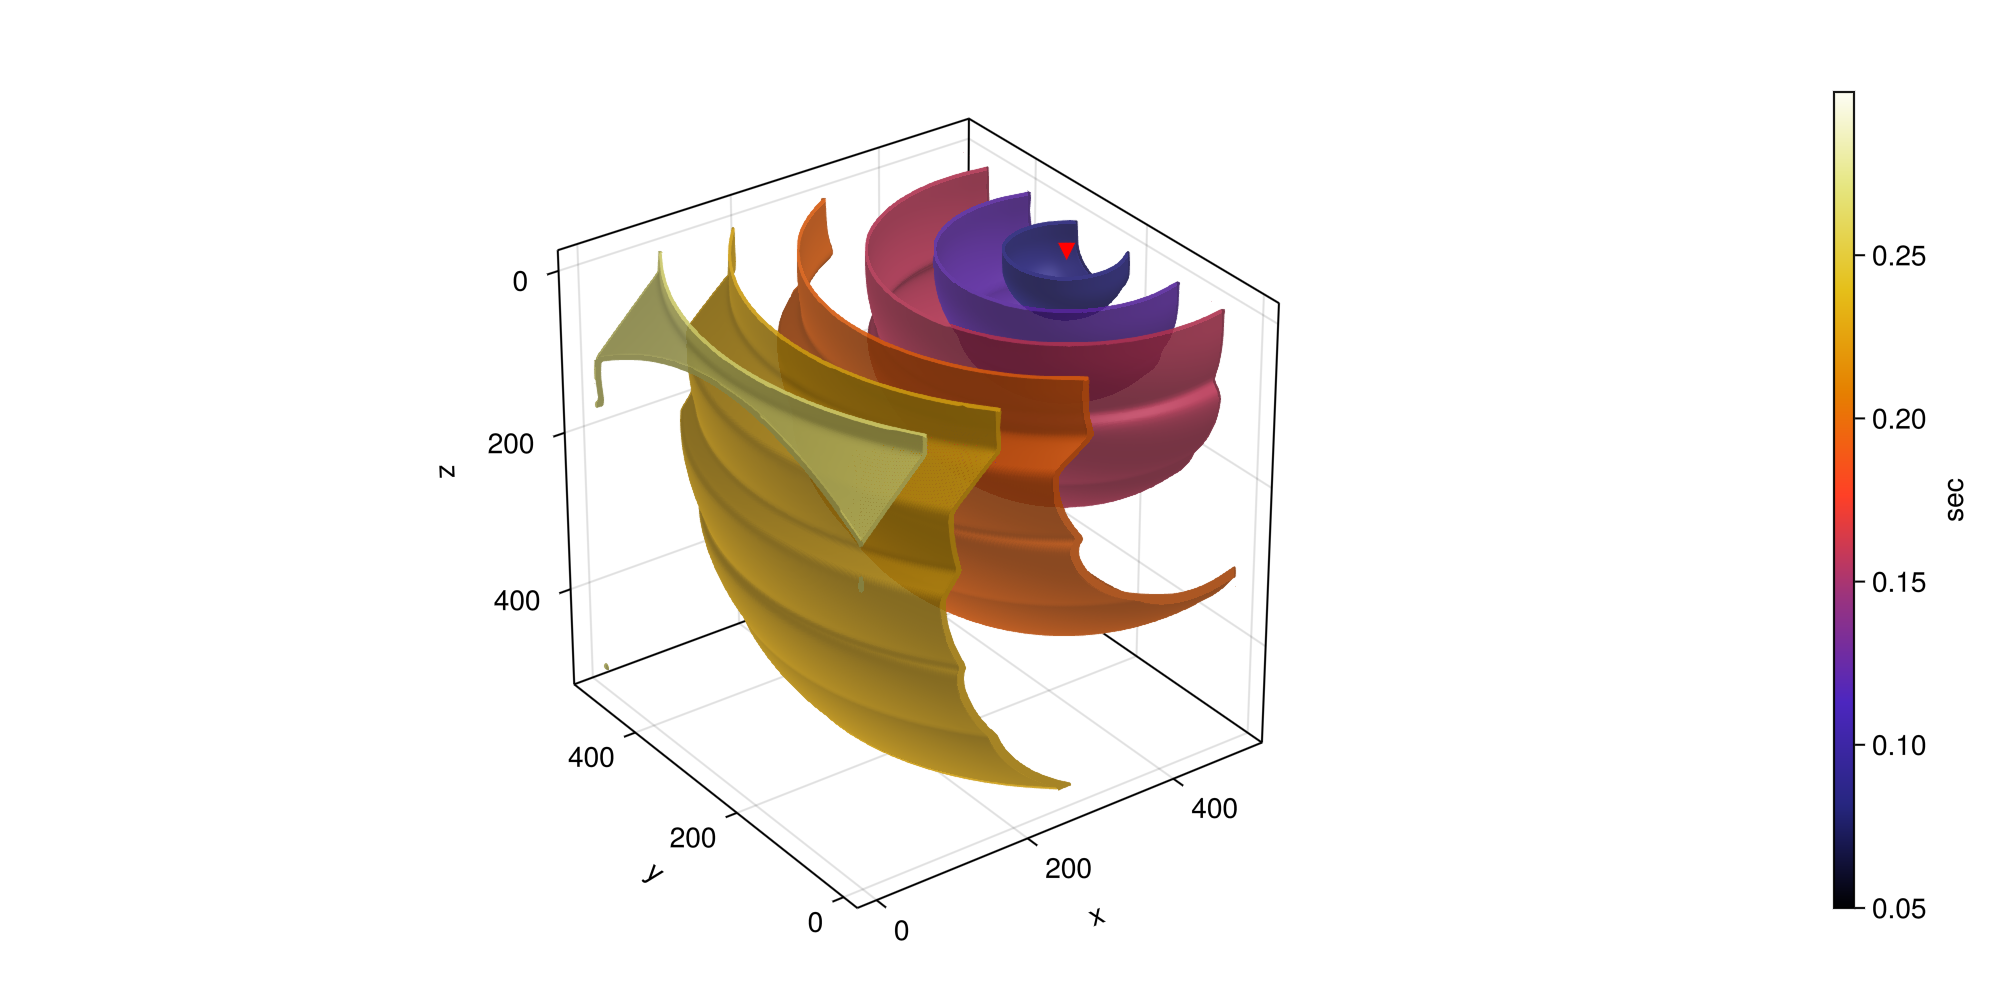

In [18]:
# 3D isosurface plot for a single receiver

receiver_index = 1

tt_rev = reverse(fs_result[receiver_index].traveltimes, dims=3) # flip z axis for plot 

fig = Figure(size=(1000,500))
ax = Axis3(fig[1, 1],
    aspect=(1, 1, 1),
    elevation=π/6,
    azimuth = 1.3 * pi,
    perspectiveness=0.1, 
    zreversed=true
)

cmap = :CMRmap
isovals = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
for (i,isoval) in enumerate(isovals)
    volume!(ax, 
            x_coords[begin]..x_coords[end],
            y_coords[begin]..y_coords[end],
            z_coords[end]..z_coords[begin],
            tt_rev,
            algorithm=:iso, isorange=0.001, isovalue=isoval,
            colormap=cmap, alpha=0.9
    )
end

rx, ry, rz = receivers[receiver_index]
scatter!(ax, [rx], [ry], [rz],  color=:red, marker=:dtriangle, markersize=12)
Colorbar(fig[1,2],
    colormap = cmap,
    limits = (minimum(isovals), maximum(isovals)),
    label = "sec",
    width=10
)

fig